In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [3]:
(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.cifar10.load_data() #load cifar10 dataset

In [4]:
#normalize the input
X_train = X_train/255.0
X_test = X_test/255.0

Labels: [9]


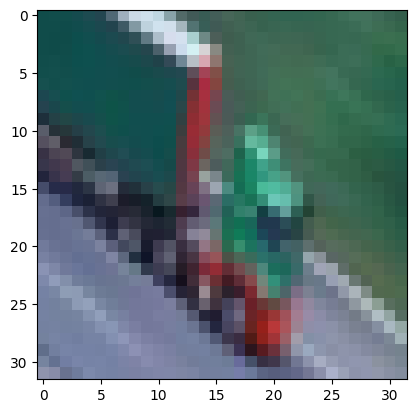

In [5]:
#visualize the data
plt.imshow(X_train[50])
print("Labels:", Y_train[50])

In [6]:
X_train.shape[-1]

3

In [7]:
def bottleneck_block(X):
    X_skip = X
    c = X.shape[-1]
    #expansion phase, 1x1 convulution to expand
    X = tf.keras.layers.Conv2D(18, (1,1), strides = 1, padding = 'same', use_bias = False)(X)
    X  = tf.keras.layers.BatchNormalization()(X)
    X = tf.keras.layers.ReLU(6.0)(X)
    #depthwise 
    X = tf.keras.layers.DepthwiseConv2D((3,3), strides = 1, padding = 'same', use_bias = False)(X)
    X = tf.keras.layers.BatchNormalization()(X)
    X = tf.keras.layers.ReLU(6.0)(X)
    #pointwise/projection
    X = tf.keras.layers.Conv2D(c, (1,1), strides = 1, padding = 'same', use_bias = False)(X)
    X = tf.keras.layers.BatchNormalization()(X)
    #skip connection
    X = tf.keras.layers.Add()([X_skip, X])
    return X

In [12]:
def mini_MN():
    X_input = tf.keras.layers.Input(shape= (32,32,3))
    # one convolutional layer
    X = tf.keras.layers.Conv2D(32, (3,3), strides = 1, padding = 'same', use_bias = False)(X_input)
    X = tf.keras.layers.BatchNormalization()(X)
    X = tf.keras.layers.Activation('relu')(X)
    # a pooling layer?
    X = tf.keras.layers.MaxPooling2D((3, 3), strides=(2, 2))(X)
    # x3 bottleneck_blocks
    X = bottleneck_block(X)
    X = bottleneck_block(X)
    X = bottleneck_block(X)
    # global avg pooling layer
    X = tf.keras.layers.GlobalAveragePooling2D()(X)
    #output layer
    X = tf.keras.layers.Dense(10, activation = 'softmax')(X)
    #create model
    model = tf.keras.Model(inputs = X_input, outputs = X)
    return model
    

In [13]:
model = mini_MN()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 15, 15,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 15, 15,    │        576 │ max_pooling2d_1[… │
│                     │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │         72 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_6 (ReLU)      │ (None, 15, 15,    │          0 │ batch_normalizat… │
│                     │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_3  │ (None, 15, 15,    │        162 │ re_lu_6[0][0]     │
│ (DepthwiseConv2D)   │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │         72 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_7 (ReLU)      │ (None, 15, 15,    │          0 │ batch_normalizat… │
│                     │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 15, 15,    │        576 │ re_lu_7[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │        128 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 15, 15,    │          0 │ max_pooling2d_1[… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 15, 15,    │        576 │ add_3[0][0]       │
│                     │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │         72 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_8 (ReLU)      │ (None, 15, 15,    │          0 │ batch_normalizat

 Total params: 6,080 (23.75 KB)

 Trainable params: 5,608 (21.91 KB)

 Non-trainable params: 472 (1.84 KB)

In [16]:
opt = tf.keras.optimizers.Adam(learning_rate = 0.001)
model.compile(optimizer = opt, loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [17]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=0.00001
)

In [18]:
history = model.fit(
    X_train, Y_train, 
    epochs=20, 
    batch_size = 64, 
    validation_split = 0.2, 
    callbacks=[reduce_lr])

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 96ms/step - accuracy: 0.4189 - loss: 1.5963 - val_accuracy: 0.3175 - val_loss: 2.0094 - learning_rate: 0.0010
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.5250 - loss: 1.3191 - val_accuracy: 0.4476 - val_loss: 1.6132 - learning_rate: 0.0010
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 108ms/step - accuracy: 0.5556 - loss: 1.2376 - val_accuracy: 0.4775 - val_loss: 1.4917 - learning_rate: 0.0010
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 97ms/step - accuracy: 0.5756 - loss: 1.1824 - val_accuracy: 0.5182 - val_loss: 1.3532 - learning_rate: 0.0010
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.5932 - loss: 1.1323 - val_accuracy: 0.4794 - val_loss: 1.5561 - learning_rate: 0.0010
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.6084 - loss: 1.1007 - val_accuracy: 0.5569 - val_loss: 1.2575 - learning_rate: 0.0010
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 97ms/step - accuracy: 0.6166 - 

In [19]:
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=2)
print(f'\nTest accuracy: {test_acc}')

313/313 - 2s - 7ms/step - accuracy: 0.6555 - loss: 0.9668

Test accuracy: 0.6554999947547913


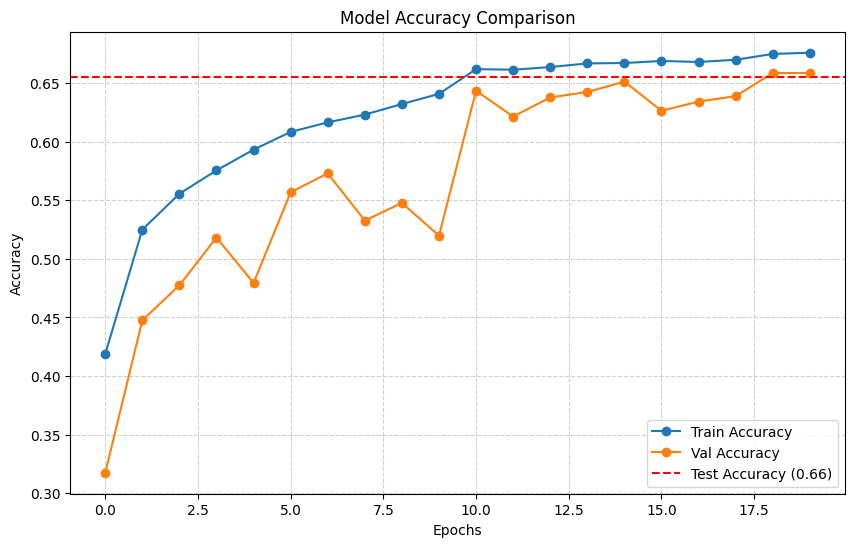

In [20]:
def plot_history(history, test_acc):
    plt.figure(figsize=(10,6))
    #plot training and validation accuracy
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='#1f77b4', marker = 'o')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='#ff7f0e', marker='o')
    #add a horizontal line for test accuracy
    plt.axhline(y=test_acc, color='red', linestyle='--', label=f'Test Accuracy ({test_acc:.2f})')

    plt.title('Model Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Call the function
plot_history(history, test_acc)

In [21]:
model.save('mini_mobilenet_v1_baseline.keras')